In [15]:
# "/lustre/LHCb/carlos.arenas/data/v009_pmu7-fn0k-fc0-ww3_inelastic_none_1_1e4.hepmc"

path = "/lustre/LHCb/carlos.arenas/data/v009_pb-pb-pmu0.0018-fn0k-fc0-ww3_inelastic_none_1_1e6.hepmc"

with open(path, "r") as file:
    lines = file.readlines()
    print(len(lines))

event_lines = []
for i, line in enumerate(lines):
    values = line.split(" ")

    if values[0] == "E":
        event_id = int(values[1])
        event_lines.append([event_id, i])

event_lines.append([0, len(lines)])

print(f"Hay {len(event_lines) - 1} eventos")

10084067
Hay 172 eventos


In [29]:
pdg_id_dicc = {11: r"$e^-$", -11: r"$e^+$", 13: r"$\mu^-$", -13: r"$\mu^+$", 22:r"$\gamma$", 111: r"$\pi^0$", 130:r"$K_L^0$", 211: r"$\pi^+$", -211: r"$\pi^-$", 310:r"$K_S^0$", 321: r"$K^+$",
               -321: r"$K^-$", 2112: "$n^0$", 2212: r"$p^+$", -2212: r"$p^-$"}

def text2list(text):

    # Elimina los espacios blancos.
    import re
    text = re.sub(r"\s+", "", text)

    text = text[1:-1]
    l = text.split(",")

    if l == ['']:
        # print(f"Este venia vacio: {text}")
        return []
    
    try:
        l = [int(x) for x in l]
    except:
        print(f"Exception ocurred with: {l}")
        return None
    
    return l

def for_all_events(func):
    def looped_func():
        global event_nr
        for i in range(len(event_lines) - 1):
            event_id = event_lines[i][0]
            start_line = event_lines[i][1]
            end_line = event_lines[i+1][1]

            func(event_id, start_line, end_line)
            event_nr += 1
        return

    return looped_func

def for_single_event(func):
    def func_event1():
        global event_nr
        event_id = event_lines[event_nr][0]
        start_line = event_lines[event_nr][1]
        end_line = event_lines[event_nr+1][1]
        func(event_id, start_line, end_line)
        return
    return func_event1

In [17]:
def fill_dicc(event_id, start_line, end_line):
    global vertices_particles
    global particles_vertex
    global particles_pid
    global particles_nhit

    global vertices_location
    global particles_momenta

    vertices_particles.clear()
    particles_vertex.clear()
    particles_pid.clear()
    particles_nhit.clear()

    vertices_location.clear()
    particles_momenta.clear()

    vertices_particles[0] = []
    vertices_location[0] = None

    for i in range(end_line - start_line):
        line = lines[start_line + i]
        values = line.split(" ")

        if values[0] == "V":
            vertex_id = int(values[1])
            vertex_particles = text2list(values[3])
            
            # vertices_particles.append([vertex_id, vertex_particles])
            vertices_particles[vertex_id] = vertex_particles

            try:
                x = float(values[5])
                y = float(values[6])
                z = float(values[7])
                vertices_location[vertex_id] = np.array([x, y, z])/1000
            except:
                vertices_location[vertex_id] = None
                
        if values[0] == "P":
            particle_id = int(values[1])
            vertex_id = int(values[2])
            pdg_id = int(values[3])

            particles_vertex[particle_id] = vertex_id
            particles_pid[particle_id] = pdg_id

            px = float(values[4])
            py = float(values[5])
            pz = float(values[6])

            particles_momenta[particle_id] = [px, py, pz]

        if values[0] == "A":
            if values[2] == "RawBankLinks":
                particle_id = int(values[1])
                particle_banks = values[3:-1]
                particle_nhit = len(particle_banks)

                particles_nhit[particle_id] = particle_nhit

def fill_directed_vertices_links():
    global directed_vertices_links
    global birth_death_dicc

    directed_vertices_links.clear()
    birth_death_dicc.clear()

    # Con sets ya no me tengo que preocupar de que haya duplicados
    directed_vertices_links = {vertex: set() for vertex in vertices_particles}
    directed_vertices_links[0] = set()

    for vertex, particles in vertices_particles.items():
        for particle in particles:
            mother_vertex = particles_vertex[particle]

            directed_vertices_links[mother_vertex].add(vertex)

            birth_death_dicc[particle] = [mother_vertex, vertex]

    for particle, vertex in particles_vertex.items():
        if not particle in birth_death_dicc.keys():
            birth_death_dicc[particle] = [vertex, None]

def fill_vertices_output():
    global mother_vertices

    global vertices_output

    vertices_output.clear()

    vertices_output = {vertex: [] for vertex in vertices_particles}

    for vertex in mother_vertices:
        vertices_output[vertex] = []

    for particle, vertex in particles_vertex.items():
        vertices_output[vertex].append(particle)

In [18]:
def get_start_end_points(particle):
    global particles_vertex
    global vertices_location
    global birth_death_dicc

    mother_vertex = particles_vertex[particle]
    start_point = vertices_location[mother_vertex]

    death_vertex = birth_death_dicc[particle][1]
    if death_vertex != None:
        end_point = vertices_location[death_vertex]
    else:
        momentum = particles_momenta[particle]
        module = np.sqrt(momentum[0]**2 + momentum[1]**2 + momentum[2]**2)

        sp = np.array(start_point)/1000
        ep = sp + 2*np.array(momentum)/module

    return sp, ep

In [19]:
def for_all_vertices_in_chain(upon_visite_func):
    def looped_func(obj, starting_vertex = 0):
        global directed_vertices_links

        visited_vertices = {vertex: 0 for vertex in vertices_particles}
        visited_vertices[0] = 0

        def visitar(obj, vertex):
            # print("Se esta visitando algo")
            visited_vertices[vertex] = 1
            current_chain.append(vertex)

            skip = upon_visite_func(obj, vertex)
            if skip: return

            for daughter_vertex in directed_vertices_links[vertex]:
                if visited_vertices[daughter_vertex] == 0:
                    visitar(obj, daughter_vertex)

        visitar(obj, starting_vertex)

    return looped_func

class counter():
    def __init__(self):
        self.value = 0

@for_all_vertices_in_chain
def sum_hits(hit_counter, this_vertex):
    # print("Se esta haciendo algo")
    for particle in vertices_output[this_vertex]:
        # print("Se esta haciendo algo")
        try:
            nhit = particles_nhit[particle]
            hit_counter.value += nhit
        except KeyError:
            pass

    skip = False
    return skip

class hist_hits_pdg():
    def __init__(self, pdgs):
        self.hist_hits = {pdg: [] for pdg in pdgs}
        self.pdgs = pdgs
        self.current_pdg = pdgs[0]

    def fill_self(self):
        for pdg in self.pdgs:
            self.current_pdg = pdg
            count_hits_per_pid(self, 0)


@for_all_vertices_in_chain
def count_hits_per_pid(obj, vertex):

    skip = False
    for particle in vertices_particles[vertex]:
        # print("Se esta haciendo algo")
        if particles_pid[particle] == obj.current_pdg:
            # print("Se encontró kei short")
            skip = True

            hit_counter = counter()
            sum_hits(hit_counter, vertex)
            obj.hist_hits[obj.current_pdg].append(hit_counter.value)

    return skip

@for_all_vertices_in_chain
def count_KS(KS_counter, vertex):
    skip = False
    for particle in vertices_particles[vertex]:
        # print("Se esta haciendo algo")
        if particles_pid[particle] == 310:
            skip = True

            KS_counter.value += 1
            
    return skip

@for_all_vertices_in_chain
def plot_particles(ax, vertex):
    import numpy as np
    global particles_momenta
    # Faltarían mas variables globales por incluir, pero bué

    for particle in vertices_output[vertex]:
        death_vertex = birth_death_dicc[particle][1]

        if death_vertex != None:
            start_point = vertices_location[vertex]
            end_point = vertices_location[death_vertex]

            if start_point is not None and end_point is not None:
                sp = start_point
                ep = end_point

                ax.plot([sp[0], ep[0]], [sp[1], ep[1]], linestyle = "--", alpha = 0.7)

        else:
            start_point = vertices_location[vertex]

            if start_point is not None:

                momentum = particles_momenta[particle]
                module = np.sqrt(momentum[0]**2 + momentum[1]**2 + momentum[2]**2)

                sp = start_point
                ep = sp + np.array(momentum)/module

                ax.plot([sp[0], ep[0]], [sp[1], ep[1]], linestyle = "--", alpha = 0.7)

    mother_particles = vertices_particles[vertex]
    if len(mother_particles) == 1:
        mother_vertex = particles_vertex[mother_particles[0]]

        sp = vertices_location[mother_vertex]
        ep = vertices_location[vertex]

        if sp is not None and ep is not None:
            ax.plot([sp[0], ep[0]], [sp[1], ep[1]], linestyle = "--", alpha = 0.7)


    skip = False
    return skip

@for_all_vertices_in_chain
def find_true_mother_vertices(obj, vertex):
    P = vertices_location[vertex]
    if P is not None:
        x = P[0]
        if x > 27 and x < 30:
            hit_counter = counter()
            sum_hits(hit_counter, vertex)

            if hit_counter.value > 0:
                obj.append(vertex)

            skip = True
            return skip

    skip = False
    return skip

@for_all_vertices_in_chain
def find_all_KS0(KS0_ids, vertex):
    for particle in vertices_particles[vertex]:
        if particles_pid[particle] == 310:
            KS0_ids.append(particle)

    skip = False
    return skip

def plot_all_KS0(ax):
    KS0_ids = []
    find_all_KS0(KS0_ids, 0)

    for particle in KS0_ids:
        death_vertex = birth_death_dicc[particle][1]
        plot_particles(ax, death_vertex)

In [20]:
def find_true_mother_particles():
    mother_vertices = []
    find_true_mother_vertices(mother_vertices, 0)

    # print(mother_vertices)

    mother_particles = [vertices_particles[vertex][0] for vertex in mother_vertices]
    # print([particles_pid[particle] for particle in mother_particles])
    first_particles = [vertices_output[vertex][0] for vertex in mother_vertices]
    # print(first_particles)
    # print([particles_pid[particle] for particle in first_particles])

    mother_particles = []
    for vertex in mother_vertices:
        for particle in vertices_particles[vertex]:
            if particles_pid[particle] != 90:
                mother_particles.append(particle)
            else:
                mother_particles.append(*vertices_output[vertex])

    # print("Madres: 9")
    # print([particles_pid[particle] for particle in mother_particles])

    return mother_particles

In [21]:
def get_tree_path(vertex):
    path = [vertex]
    current_vertex = vertex
    for j in range(500):
        try:
            mother_particles = vertices_particles[current_vertex]
            mother_vertex = particles_vertex[mother_particles[0]]

            path.append(mother_vertex)
            current_vertex = mother_vertex
        except:
            break

    path = [path[-(i+1)] for i in range(len(path))]
    return path

def search_common_path(particles):
    paths = []
    for particle in particles:
        mother_vertex = particles_vertex[particle]
        paths.append(get_tree_path(mother_vertex))

    common_path = []

    max_len = max([len(path) for path in paths])
    for i in range(max_len):
        same_path = True
        for j in range(len(paths)-1):
            if paths[j][i] != paths[j+1][i]:
                same_path = False

        if same_path:
            common_path.append(paths[0][i])
        else:
            return common_path

    return common_path

def get_last_common_particle():
    global particles_nhit

    particles_with_hits = list(particles_nhit.keys())

    if len(particles_with_hits) == 1:
        return particles_with_hits[0]

    common_path = search_common_path(particles_with_hits)

    # Sacar la buena partícula:
    try:
        for out_particle in vertices_output[common_path[-2]]:
            if birth_death_dicc[out_particle][1] == common_path[-1]:
                return out_particle
                # print(f"{particles_pid[out_particle]}: {[particles_pid[particle] for particle in vertices_output[common_path[-1]]]}: {common_path}")
                # print()
    except:
        print(f"Hubo un error: {common_path}")
        return None

In [22]:
import sys
sys.path.insert(0, "cobra/src")           # so Python can find the cobra package
from cobra import load_detector_from_yaml

detector = load_detector_from_yaml("/lustre/LHCb/carlos.arenas/cobra/config/codex-beta.yaml")

In [23]:
import pyhepmc
import numpy as np
from cobra import StripDecoder
from cobra.geometry import transform_surface
from cobra.geometry import strip_to_global_position

def strip_points(detector, strips):
    points = []
    for module_id in {int(r[0]) for r in strips}:      # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = [r for r in strips if int(r[0]) == module_id and int(r[1]) == slot]
            phi_strips = [int(r[2]) for r in here if int(r[4]) == 0]
            eta_strips = [int(r[2]) for r in here if int(r[4]) == 1]
            singlet = detector.singlets[module.singlet_ids[slot]]
            for phi in phi_strips:
                for eta in eta_strips:
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)
                    points.append(point)
    return np.array(points)

def get_hit_points(event_nr):
    with pyhepmc.open(path) as f:
        it = iter(f)
        for i in range(event_nr):
            next(it)
        event = next(it)

    rows = []
    for key, value in event.attributes.items():
        if key.startswith("RawBank_"):
            module, strip, time0, time1 = [int(x) for x in str(value).split()]
            rows.append([0, module, strip, time0, time1])           # 0 = sourceID placeholder

    raw_banks = np.array(rows, dtype=np.int16)
    strips = StripDecoder()._process(raw_banks)

    points = strip_points(detector, strips.tolist())

    return points

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_detector(ax, view = "front", zoom = "zoom_in"):
    for module in detector.modules.values():
        corners = np.vstack([transform_surface(detector, module, detector.singlets[s]) for s in module.singlet_ids])
        lo, hi = corners.min(axis=0), corners.max(axis=0)
        if view == "front":
            ax.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1], facecolor="lightgreen", alpha=0.3))
        elif view == "side":
            ax.add_patch(plt.Rectangle((lo[0], lo[2]), hi[0] - lo[0], hi[2] - lo[2], facecolor="lightgreen", alpha=0.3))

    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_aspect("equal")

    if zoom == "zoom_in":
        ax.set_xlim(left= 29, right= 33)
        ax.set_ylim(bottom= -6, top= -3)
    elif zoom == "zoom_medium":
        ax.set_xlim(left= 25, right= 33)
        ax.set_ylim(bottom= -6, top= -2)
    elif zoom == "zoom_out":
        ax.set_xlim(left=-10, right=32)
        ax.set_ylim(bottom=-10, top=25)

In [26]:
# Por ahora ignora esto
class Event_data():
    def __init__(self):
        self.vertices_particles = {}
        self.vertices_particles = {}
        self.particles_vertex = {}
        self.particles_pid = {}
        self.particles_nhit = {}

        self.vertices_location = {}
        self.particles_momenta = {}

        # fill_event(self)

def plot_event():
    # Preparacion del plotteo
    fig, ax = plt.subplots()
    plot_detector(ax, zoom = "zoom_medium")

    points = get_hit_points(event_nr)
    ax.scatter(points[:,0], points[:,1])

    plot_particles(ax, 0)
    plt.show()

    fig, ax2 = plt.subplots()

    plot_detector(ax2, zoom = "zoom_medium")
    ax2.scatter(points[:,0], points[:,1])

    particles_with_hits = [particle for particle in particles_nhit]
    common_path = search_common_path(particles_with_hits)

    plot_particles(ax2, common_path[-1])
    plt.show()


    # Partículas madre verdaderas
    mother_particles = find_true_mother_particles()
    # print(f"Madres: {mother_particles}")

    end_vertices = []
    for particle in mother_particles:
        end_vertex = birth_death_dicc[particle][1]
        if end_vertex == None:
            end_vertices.append(particles_vertex[particle])
        else:
            end_vertices.append(end_vertex)

    # end_vertices = [birth_death_dicc[particle][1] for particle in mother_particles]
    
    fig, ax3 = plt.subplots()
    plot_detector(ax3)
    ax3.scatter(points[:,0], points[:,1])
    for vertex in end_vertices:
        if vertex is not None:
            plot_particles(ax3, vertex)

    plt.show()

def plot_simple_event():
    points = get_hit_points(event_nr)

    # Partículas madre verdaderas
    mother_particles = find_true_mother_particles()

    end_vertices = []
    for particle in mother_particles:
        end_vertex = birth_death_dicc[particle][1]
        if end_vertex == None:
            end_vertices.append(particles_vertex[particle])
        else:
            end_vertices.append(end_vertex)
    
    fig, ax3 = plt.subplots()
    plot_detector(ax3)
    ax3.scatter(points[:,0], points[:,1])
    for vertex in end_vertices:
        if vertex is not None:
            plot_particles(ax3, vertex)

    plt.show()

In [30]:
vertices_particles = {}
particles_vertex = {}
particles_pid = {}
particles_nhit = {}

vertices_location = {}
particles_momenta = {}

directed_vertices_links = {}
birth_death_dicc = {}

mother_vertices = []

vertices_input = []
vertices_output = {}

current_chain = []
chains = []
current_chain_hits = 0
chains_hits = []

hist_obj = hist_hits_pdg([2112, 321, 130, 2212, 11, -211, 13, -13, 211, -11, 90, -2212, 130, 310])

all_particles_pid = set()
all_mother_particles_pid = set()

event_nr = 0

@for_all_events
def main(event_id, start_line, end_line):

    fill_dicc(event_id, start_line, end_line)

    fill_directed_vertices_links()
    fill_vertices_output()

    # print(find_mother_particles_pid())

    # count_hits_per_chain()
    hit_counter = counter()
    sum_hits(hit_counter, 0)
    print(f"Total hits of the Event: {hit_counter.value}")
    chains_hits.append(hit_counter.value)
    chains.append(current_chain)


    global hist_obj
    hist_obj.fill_self()

    plot_simple_event()

    """
    KS_counter = counter()
    count_KS(KS_counter, 0)
    print(f"Hay: {KS_counter.value} K shorts")
    """

    """
    global all_particles_pid
    global all_mother_particles_pid
    for particle in particles_pid:
        all_particles_pid.add(particles_pid[particle])
    try:
        all_mother_particles_pid.add(particles_pid[vertices_particles[common_path[-1]][0]])
    except:
        pass

    print(f"El common path es: {common_path}")
    common_ancestor = get_last_common_particle()
    if common_ancestor != None:
        print(f"La partícula madres es: {particles_pid[common_ancestor]}")
        all_mother_particles_pid.add(particles_pid[common_ancestor])
    # print(particles_pid[vertices_particles[common_path[2]][0]])
    """
    
    """
    particle_chain = [[particles_pid[particle] for particle in vertices_output[vertex]] for vertex in common_path]
    for x in particle_chain:
        print(x)
    """
  
    # print([particles_pid[particle] for particle in vertices_output[0]])

    print(f"El evento {event_id} tiene {len(vertices_particles)} vértices y {chains_hits[-1]} hits")

Total hits of the Event: 24


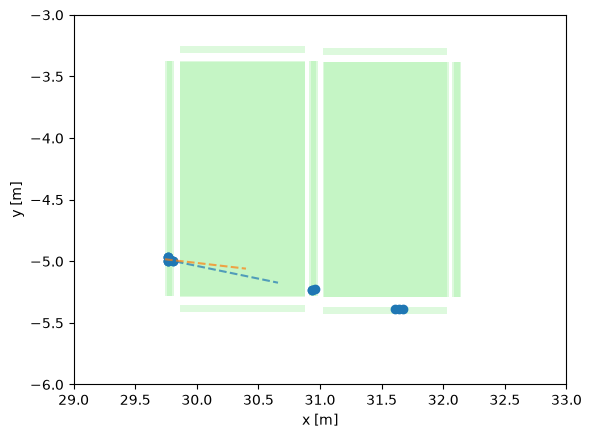

El evento 167355 tiene 3 vértices y 24 hits
Total hits of the Event: 34


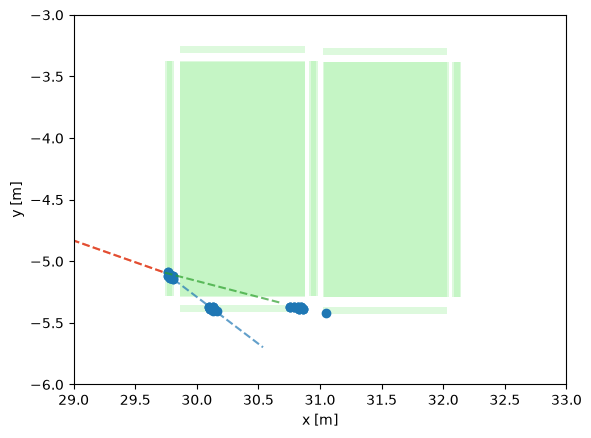

El evento 1631835 tiene 21081 vértices y 34 hits
Total hits of the Event: 15


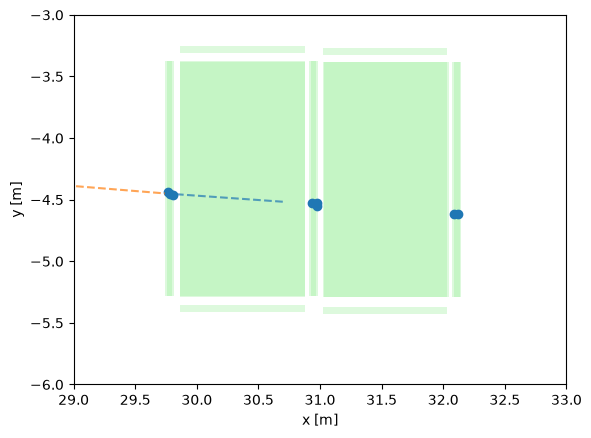

El evento 2971415 tiene 10836 vértices y 15 hits
Total hits of the Event: 28


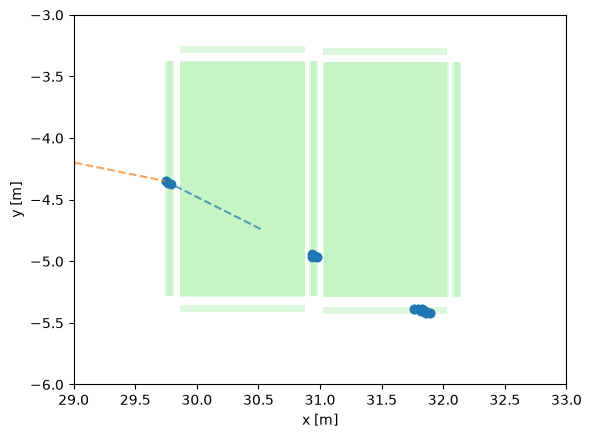

El evento 3546055 tiene 19056 vértices y 28 hits
Total hits of the Event: 16


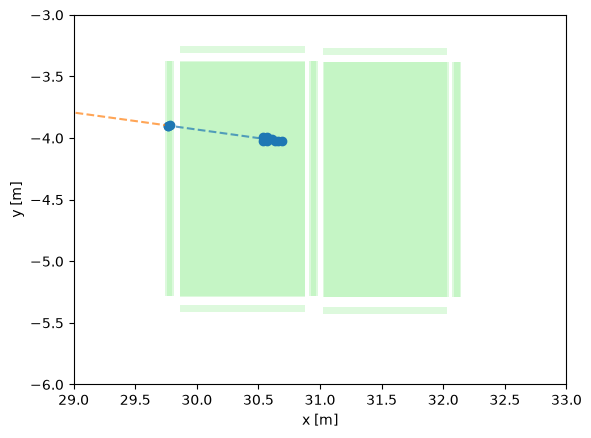

El evento 6387126 tiene 16067 vértices y 16 hits
Total hits of the Event: 15


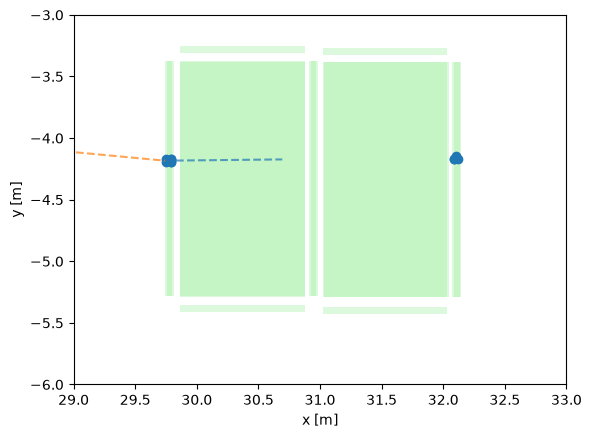

El evento 7461935 tiene 30476 vértices y 15 hits
Total hits of the Event: 17


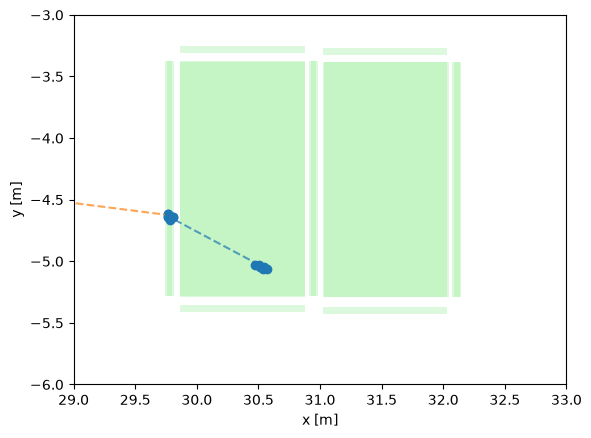

El evento 8852258 tiene 17183 vértices y 17 hits
Total hits of the Event: 16


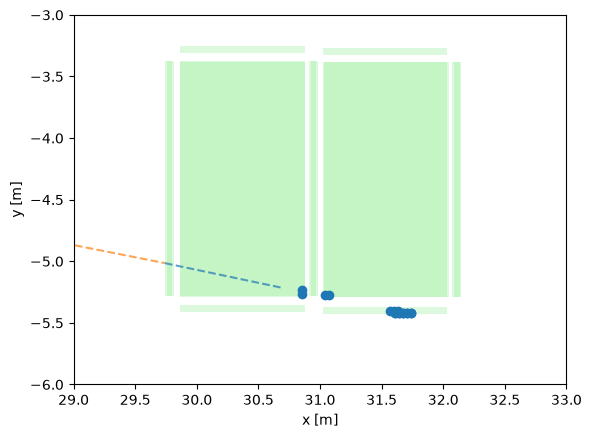

El evento 9390926 tiene 18253 vértices y 16 hits
Total hits of the Event: 17


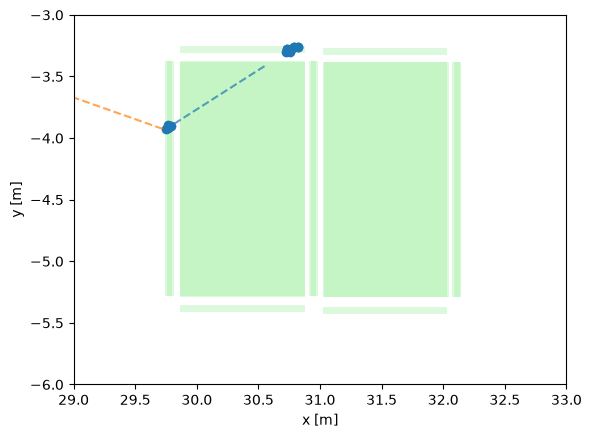

El evento 9429589 tiene 8965 vértices y 17 hits
Total hits of the Event: 22


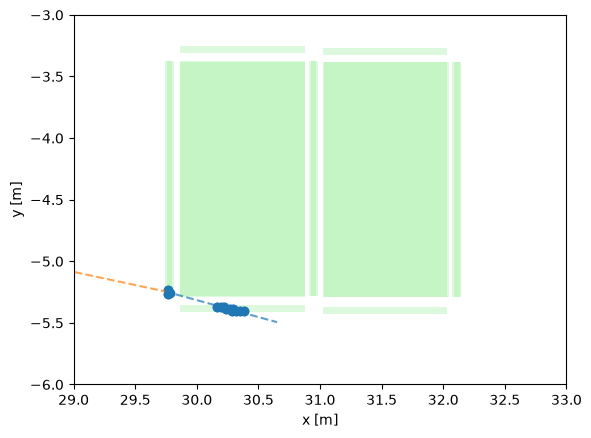

El evento 9861740 tiene 25813 vértices y 22 hits
Total hits of the Event: 17


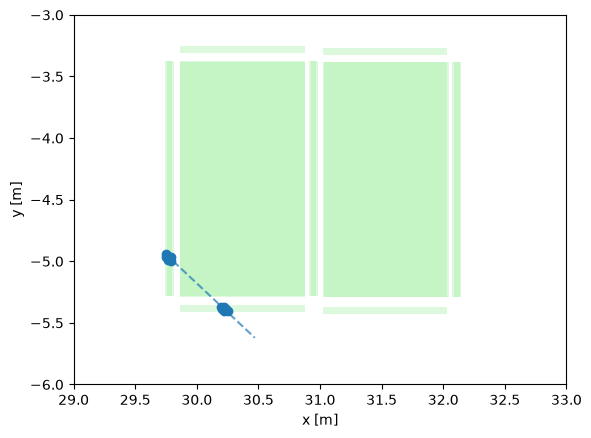

El evento 12229165 tiene 2 vértices y 17 hits
Total hits of the Event: 19


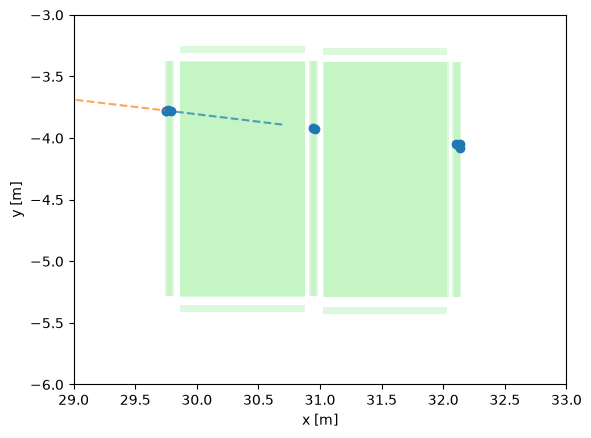

El evento 13113656 tiene 9270 vértices y 19 hits
Total hits of the Event: 18


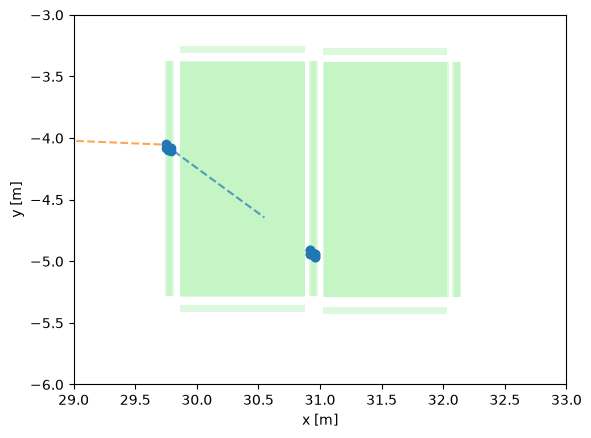

El evento 17023790 tiene 28606 vértices y 18 hits
Total hits of the Event: 7


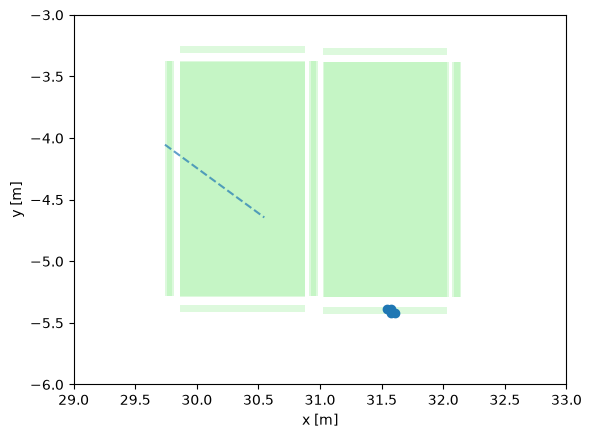

El evento 17023791 tiene 2 vértices y 7 hits
Total hits of the Event: 24


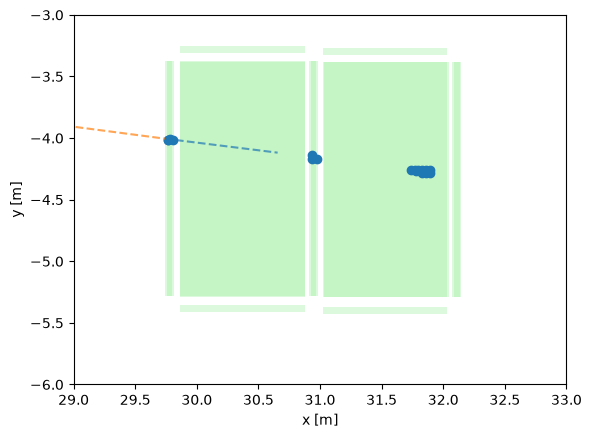

El evento 17471109 tiene 21220 vértices y 24 hits
Total hits of the Event: 15


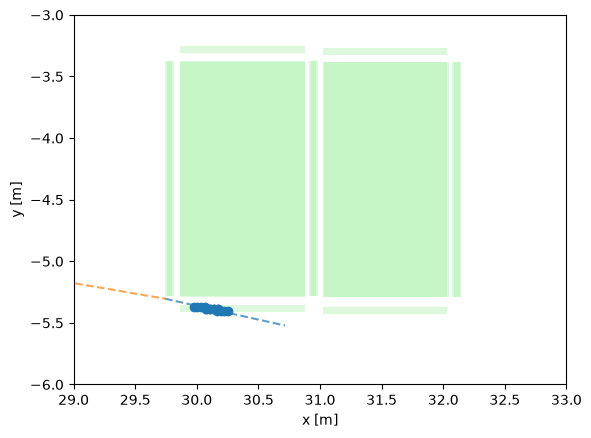

El evento 17949622 tiene 12792 vértices y 15 hits
Total hits of the Event: 22


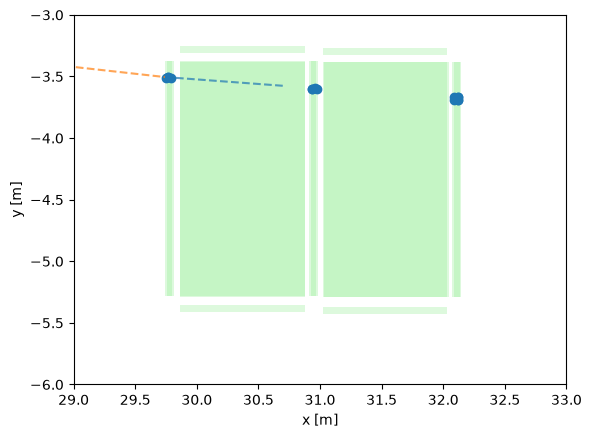

El evento 20814456 tiene 24471 vértices y 22 hits
Total hits of the Event: 20


: 

In [31]:
main()

# print(all_particles_pid)
# print("Madres: ")
# print(all_mother_particles_pid)

In [ ]:
for key, value in vertices_location.items():
    print(value)

In [ ]:
for pdg in [2112, 321, 130, 2212, 11, -211, 13, -13, 211, -11, 90, -2212, 130, 310]:

    hits = hist_obj.hist_hits[pdg]
    if hits != []:
        plt.hist(hits, bins = range(1, max(hits) + 2, 2))

    plt.xlabel('Number of hits')
    plt.ylabel('Number of particles')
    try:
        pdg_name = pdg_id_dicc[pdg]
    except KeyError:
        pdg_name = ""

    plt.title(rf"PID: {pdg}, {pdg_name}")

    plt.show()

In [ ]:
for particle in particles_nhit:
    mother_vertex = particles_vertex[particle]
    print(get_tree_path(mother_vertex))

particles_with_hits = [particle for particle in particles_nhit]
print("Common path:")
common_path = search_common_path(particles_with_hits)
print(common_path)

common_ancestor = vertices_particles[common_path[-1]][0]
print(f"Common ancestor: {particles_pid[common_ancestor]}")


In [ ]:
for particle, pid in particles_pid.items():
    if birth_death_dicc[particle][1] == None:
        try:
            print(pdg_id_dicc[pid])
        except:
            print(f"Unkown ({pid})")

In [ ]:
for particle in particles_nhit:
    print(particles_pid[particle])

In [ ]:
@for_single_event
def print_raw_bank_links(event_id, start_line, end_line):
    for line in lines[start_line:end_line]:
        values = line.split()

        if values[0] == "A":
            if values[2] == "RawBankLinks":
                print(line)

            if values[2].startswith("RawBank_"):
                print(line)

print_raw_bank_links()
print(particles_nhit)

In [ ]:
hist_hits = []

def contar_hits_KS(hist_hits):
    for particle, pdg_id in particles_pid.items():
        if pdg_id == 2112:
            try:
                nhit = particles_nhit[particle]
                if nhit != 0:
                    hist_hits.append(nhit)
            except:
                pass

@for_all_events
def main2(event_nr, start_line, end_line):
    fill_dicc(event_nr, start_line, end_line)
    contar_hits_KS(hist_hits)

main2()
print(hist_hits)

import matplotlib.pyplot as plt

plt.hist(hist_hits)

plt.xlabel('Number of hits')
plt.ylabel('Number of particles')
plt.title(r"PID: 111, $\pi^0$")

plt.show()